# 미니프로젝트: 차원 축소와 SHAP Value (Vibe Coding)

#### <목표>
오늘 배운 **mRMR, Boruta, SHAP Value**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 인코딩된 고객 정보로 이탈 여부 예측 및 변수 해석 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day5_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)
- 지난 미니프로젝트에서 다룬 전처리를 모두 적용한 뒤 시작하세요.

**[과제]** 써니는 어제 실습에서 사용한 통신사 고객 이탈(Churn) 데이터를 활용하여 분석을 진행하고자 합니다. 필요한 라이브러리와 데이터를 불러오세요.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from mrmr import mrmr_classif
from boruta import BorutaPy

import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv("../dataset/day5_miniproject.csv")
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [4]:
# 구조 확인
print("=== 데이터 크기 ===")
print(f"행: {data.shape[0]:,}  |  열: {data.shape[1]}")

print("\n=== 컬럼 정보 (.info) ===")
data.info()

print("\n=== 타겟(Churn) 분포 ===")
print(data["Churn"].value_counts())

print("\n=== 상위 5행 ===")
data.head()

=== 데이터 크기 ===
행: 7,043  |  열: 20

=== 컬럼 정보 (.info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            6832 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6903 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null 

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**[과제]** 써니는 어제 진행한 통신사 고객 이탈 데이터 전처리 과정을 재사용하고자 합니다. Agent 기능을 활용하여 '머신러닝 Day4. 미니프로젝트.ipynb' 파일에서 전처리 코드를 찾아 실행하고 동일한 데이터 전처리 결과를 재현해 보세요.

> 입력변수, 출력변수 분할 / 학습 데이터, 테스트 데이터 분할 / 결측치 처리 / 스케일링, 인코딩

In [ ]:
[프롬프트]

지금 ipynb 코드가 있는 곳에 '머신러닝 Day 4.미니프로젝트.ipynb'가 있을거야.
ipynb 파일을 분석해서

1. 입력변수, 출력변수 분할
2. 학습데이터, 테스트 데이터 분할
3. 결측치 처리
4. 스케일링 인코딩

했던 코드 다 가지고 와서 나한테 줘.

In [7]:
from sklearn.impute import KNNImputer

# ── 타겟 변수 인코딩 ─────────────────────────────────────────────
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# ── 1. 입력변수 / 출력변수 분할 ──────────────────────────────────
X = data.drop(columns='Churn')
y = data['Churn']

# ── 2. 학습 데이터 / 테스트 데이터 분할 ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. 결측치 처리 ───────────────────────────────────────────────
# 범주형 → 최빈값 대치 (train 기준)
for col in ['InternetService', 'PaymentMethod']:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col]  = X_test[col].fillna(mode_val)

# TotalCharges → 중앙값 대치 (train 기준)
median_val = X_train['TotalCharges'].median()
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(median_val)
X_test['TotalCharges']  = X_test['TotalCharges'].fillna(median_val)

# tenure, MonthlyCharges → KNN Imputer (train 기준)
knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
X_train[knn_cols] = imputer.fit_transform(X_train[knn_cols])
X_test[knn_cols]  = imputer.transform(X_test[knn_cols])

# ── 4. 스케일링 & 인코딩 ─────────────────────────────────────────
# Label Encoding (이진 범주형)
binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col]  = X_test[col].map(mapping)

# One-Hot Encoding (다중 범주형)
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=False)
X_test  = pd.get_dummies(X_test,  columns=ohe_cols, drop_first=False)

# train/test 컬럼 불일치 방지
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# StandardScaler (수치형)
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print("전처리 완료!")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train 분포:\n{y_train.value_counts()}")

전처리 완료!
X_train: (5634, 40), X_test: (1409, 40)
y_train 분포:
Churn
0    4139
1    1495
Name: count, dtype: int64


In [8]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit 

## 1) 다중공선성 확인

**[과제]** 써니는 인코딩된 변수들의 상관행렬을 히트맵으로 그려보고 어떤 변수끼리 상관관계가 높은지 AI와 함께 확인해 보세요.

In [ ]:
[프롬프트]

인코딩된 변수들을 가지고 히트맵을 그려서 변수간 상관관계가 어떤지 궁금해.
관련 코드 작성해줘.

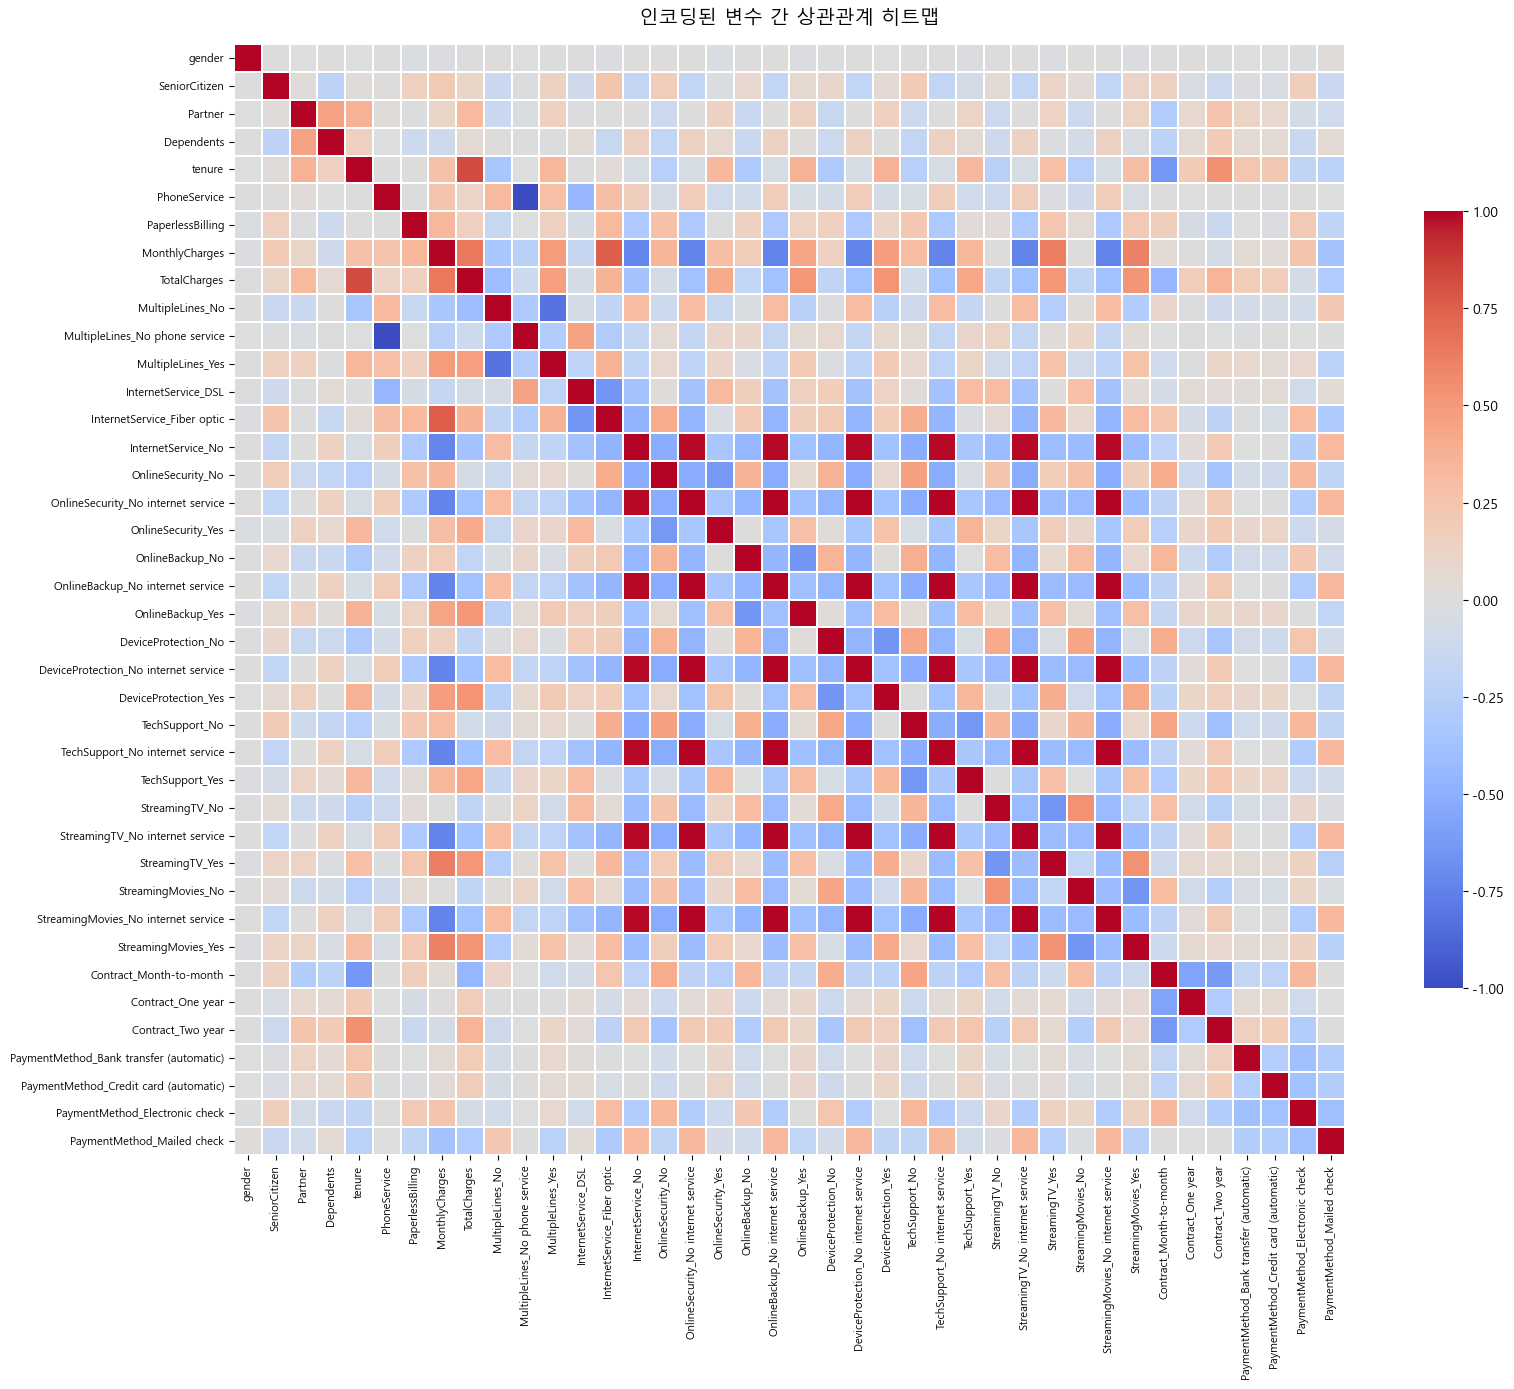

In [4]:
# 인코딩된 X_train 변수들의 상관관계 히트맵
plt.figure(figsize=(18, 14))

corr_matrix = X_train.corr()

sns.heatmap(
    corr_matrix,
    annot=False,          # 변수가 많아 수치 표기 생략
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.title("인코딩된 변수 간 상관관계 히트맵", fontsize=14, pad=15)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()

**[과제]** 써니는 변수 선택법과 SHAP 분석을 적용하기 전에 전체 변수를 사용한 Random Forest 분류 모델의 성능을 기준으로 삼고자 합니다. AI와 상의하여 모델을 학습하고, Accuracy, Precision, Recall, F1-score를 계산하여 성능을 확인하는 코드를 작성해 보세요.

In [ ]:
[프롬프트]

먼저 Random Forest로 전체 변수를 학습했을 때의 성능이 궁금해.
관련 코드 작성해줘.

In [5]:
def get_classscore(real, pred, name="모델"):
    print(f"=== {name} ===")
    print("Accuracy  : %.4f" % accuracy_score(real, pred))
    print("Precision : %.4f" % precision_score(real, pred))
    print("Recall    : %.4f" % recall_score(real, pred))
    print("F1-score  : %.4f" % f1_score(real, pred))
    print()

In [6]:
# 전체 변수로 Random Forest 학습 및 성능 평가
rf_all = RandomForestClassifier(n_estimators=100, random_state=42)
rf_all.fit(X_train, y_train)

y_pred_all = rf_all.predict(X_test)
get_classscore(y_test, y_pred_all,  name="전체 변수")

=== 전체 변수 ===
Accuracy  : 0.7743
Precision : 0.5933
Recall    : 0.4759
F1-score  : 0.5282



## 2) mRMR 변수 선택

**[과제]** 써니는 mRMR을 활용해 중요한 변수를 선택해보고자 합니다. AI와 상의해서 가장 적합한 k를 결정하고 선택된 변수로 모델을 다시 학습시켜 전체 변수를 사용했을 때 때와 성능을 비교해 보세요.

In [ ]:
[프롬프트]

mRMR을 활용해서 중요한 변수를 선택해보고 싶어.

1. 사용자가 k를 결정해야하는데 여러 k 후보 중 비교 기준일 될 평가지표 추천해주고

2. 1에 대한 결정을 하면 가장 적합한 k를 찾는 코드 작성해줘.

3. 가장 적합한 k로 변수를 선택하고 선택된 모델로 Random Forest 다시 학습시키고
전체 변수로 학습했던 결과랑 성능 비교할 수 있는 코드 작성해줘.

In [7]:
# F1-score를 추천해줌 (불균형 데이터에 적합)

# 탐색할 k 후보
k_candidates = list(range(5, X_train.shape[1] + 1, 5))  # 5, 10, 15, ...

results_mrmr = []

for k in k_candidates:
    # mRMR로 상위 k개 변수 선택
    selected_features = mrmr_classif(X=X_train, y=y_train, K=k)
    
    # 선택된 변수로 RF 학습
    rf_k = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_k.fit(X_train[selected_features], y_train)
    y_pred_k = rf_k.predict(X_test[selected_features])
    
    results_mrmr.append({
        'k': k,
        'F1-score': round(f1_score(y_test, y_pred_k), 4),
        'Accuracy': round(accuracy_score(y_test, y_pred_k), 4),
        'Precision': round(precision_score(y_test, y_pred_k), 4),
        'Recall': round(recall_score(y_test, y_pred_k), 4),
    })

df_mrmr_k = pd.DataFrame(results_mrmr).set_index('k')
df_mrmr_k

100%|██████████| 40/40 [00:36<00:00,  1.08it/s]


,F1-score,Accuracy,Precision,Recall
k,,,,
5,0.5401,0.7764,0.5949,0.4947
10,0.5297,0.7530,0.5355,0.5241
15,0.4915,0.7459,0.5242,0.4626
20,0.5101,0.7587,0.5531,0.4733
25,0.5147,0.7658,0.5719,0.4679
30,0.5511,0.7850,0.6179,0.4973
35,0.5481,0.7835,0.6146,0.4947
40,0.5359,0.7800,0.6088,0.4786


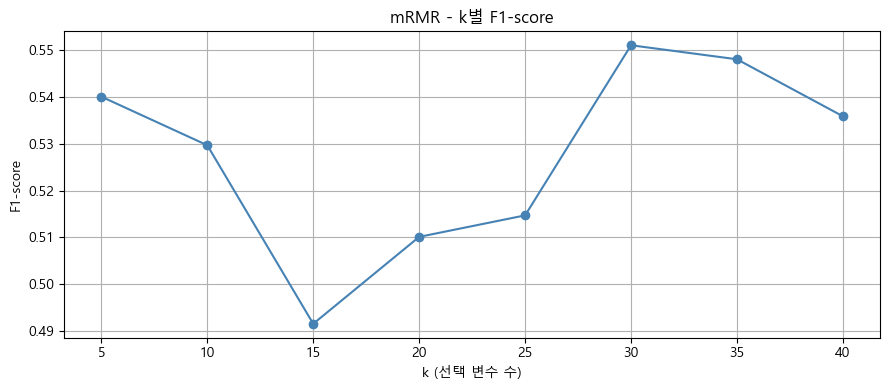

In [8]:
# F1 기준 최적 k 시각화
plt.figure(figsize=(9, 4))
plt.plot(df_mrmr_k.index, df_mrmr_k['F1-score'], marker='o', color='steelblue')
plt.xlabel('k (선택 변수 수)')
plt.ylabel('F1-score')
plt.title('mRMR - k별 F1-score')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 최적 k 출력
best_k = df_mrmr_k['F1-score'].idxmax()
print(f"최적 k: {best_k}  (F1-score: {df_mrmr_k.loc[best_k, 'F1-score']})")


최적 k: 30  (F1-score: 0.5511)


In [10]:
# 최적 k로 변수 선택
best_features_mrmr = mrmr_classif(X=X_train, y=y_train, K=best_k)
print(f"선택된 변수 ({best_k}개): {best_features_mrmr}")

100%|██████████| 30/30 [00:14<00:00,  2.09it/s]

선택된 변수 (30개): ['Contract_Month-to-month', 'PaymentMethod_Mailed check', 'OnlineSecurity_No', 'InternetService_DSL', 'TechSupport_No', 'tenure', 'PaymentMethod_Electronic check', 'InternetService_Fiber optic', 'Contract_Two year', 'OnlineBackup_No', 'PaperlessBilling', 'DeviceProtection_No', 'Contract_One year', 'Dependents', 'OnlineSecurity_Yes', 'OnlineSecurity_No internet service', 'SeniorCitizen', 'OnlineBackup_No internet service', 'Partner', 'PaymentMethod_Credit card (automatic)', 'DeviceProtection_No internet service', 'TotalCharges', 'TechSupport_No internet service', 'PaymentMethod_Bank transfer (automatic)', 'StreamingTV_No internet service', 'TechSupport_Yes', 'StreamingMovies_No internet service', 'InternetService_No', 'MonthlyCharges', 'StreamingMovies_No']


In [11]:
# 최적 k 모델 학습
rf_mrmr = RandomForestClassifier(n_estimators=100, random_state=42)
rf_mrmr.fit(X_train[best_features_mrmr], y_train)
y_pred_mrmr = rf_mrmr.predict(X_test[best_features_mrmr])

# 성능 비교 출력
get_classscore(y_test, y_pred_all,  name=f"전체 변수 ({X_train.shape[1]}개)")
get_classscore(y_test, y_pred_mrmr, name=f"mRMR 선택 변수 ({best_k}개)")

=== 전체 변수 (40개) ===
Accuracy  : 0.7743
Precision : 0.5933
Recall    : 0.4759
F1-score  : 0.5282

=== mRMR 선택 변수 (30개) ===
Accuracy  : 0.7850
Precision : 0.6179
Recall    : 0.4973
F1-score  : 0.5511



## 3) Boruta 변수 선택

**[과제]** 써니는 Boruta로도 변수를 선택해보고자 합니다. AI와 상의하여 관련 코드를 작성하세요.

In [ ]:
[프롬프트]

mRMR로 했던 것을 이번에는 Boruta로 바꿔서 해보고싶어.
관련 코드 작성해줘.

In [12]:
# ── Boruta 변수 선택 ──────────────────────────────────────────────
rf_for_boruta = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=0)

boruta_selector = BorutaPy(
    estimator=rf_for_boruta,
    n_estimators='auto',
    random_state=42,
    verbose=0
)
boruta_selector.fit(X_train.values, y_train.values)

BorutaPy(estimator=RandomForestClassifier(n_estimators=28, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x20AB5680140),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x20AB5680140)

In [13]:
# 선택된 변수 추출
best_features_boruta = X_train.columns[boruta_selector.support_].tolist()
print(f"선택된 변수 ({len(best_features_boruta)}개):")
print(best_features_boruta)

선택된 변수 (4개):
['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Month-to-month']


In [ ]:
[프롬프트]

Boruta가 확정 변수, 애매 변수로 나눈다고 했는데
애매한 변수를 변수 중요도에 따라 정렬을 하고
하나씩 넣어가며 F1-score를 비교하여 가장 좋은 변수들을 선택하고 싶어.

관련 코드 작성해줘.

In [14]:
# ── 확정 변수 / 애매 변수 분리 ────────────────────────────────────
confirmed_features = X_train.columns[boruta_selector.support_].tolist()
tentative_features = X_train.columns[boruta_selector.support_weak_].tolist()
print(f"확정 변수: {len(confirmed_features)}개")
print(f"애매 변수: {len(tentative_features)}개 → {tentative_features}")

확정 변수: 4개
애매 변수: 0개 → []


In [15]:
# ── 선택된 변수로 RF 학습 ─────────────────────────────────────────
rf_boruta = RandomForestClassifier(n_estimators=100, random_state=42)
rf_boruta.fit(X_train[best_features_boruta], y_train)
y_pred_boruta = rf_boruta.predict(X_test[best_features_boruta])

# ── 성능 비교 ─────────────────────────────────────────────────────
get_classscore(y_test, y_pred_all,    name=f"전체 변수 ({X_train.shape[1]}개)")
get_classscore(y_test, y_pred_boruta, name=f"Boruta 선택 변수 ({len(best_features_boruta)}개)")

=== 전체 변수 (40개) ===
Accuracy  : 0.7743
Precision : 0.5933
Recall    : 0.4759
F1-score  : 0.5282

=== Boruta 선택 변수 (4개) ===
Accuracy  : 0.7544
Precision : 0.5452
Recall    : 0.4519
F1-score  : 0.4942



## 4) 성능 비교 요약

**[과제]** 써니는 전체 변수/mRMR/Boruta 세 가지 방법의 성능을 표로 정리하고 변수 수를 줄였을 때 성능이 어떻게 변하는지 AI와 함께 해석해 보세요.

In [ ]:
[프롬프트]

전체 변수, mRMR 기반 변수 선택된 것, Boruta로 변수 선택된 것으로
RandomForest 학습시켰을 때 성능이 어떻게 되는지가 궁금해.

관련 코드 작성해줘.

In [16]:
# ── 성능 비교 요약 테이블 ─────────────────────────────────────────
summary = []

models = [
    ("전체 변수",              X_train.shape[1],              y_pred_all),
    (f"mRMR (k={best_k})",    best_k,                        y_pred_mrmr),
    ("Boruta",                len(best_features_boruta), y_pred_boruta),
]

for name, n_features, y_pred in models:
    summary.append({
        '방법':      name,
        '변수 수':   n_features,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-score':  round(f1_score(y_test, y_pred), 4),
    })

df_summary = pd.DataFrame(summary).set_index('방법')
df_summary

,변수 수,Accuracy,Precision,Recall,F1-score
방법,,,,,
전체 변수,40,0.7743,0.5933,0.4759,0.5282
mRMR (k=30),30,0.7850,0.6179,0.4973,0.5511
Boruta,4,0.7544,0.5452,0.4519,0.4942


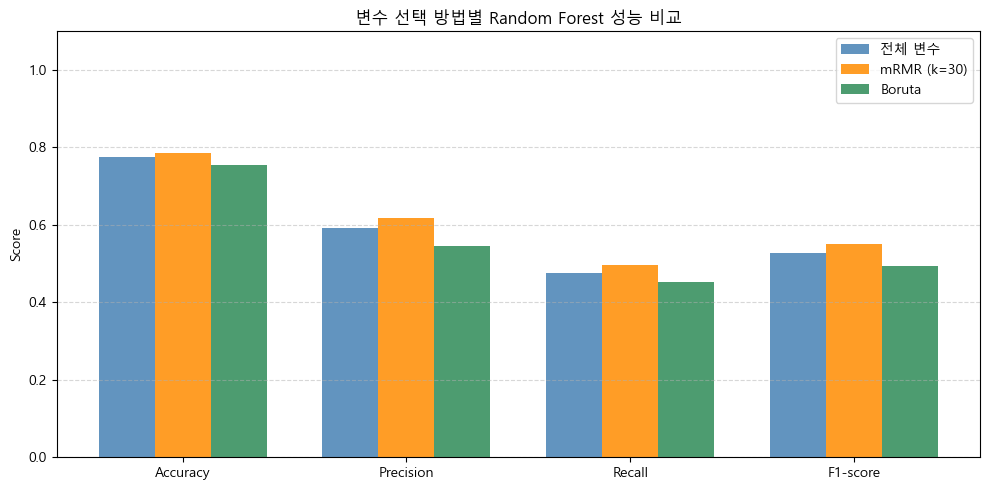

In [17]:
# ── 시각화 ────────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (method, row) in enumerate(df_summary.iterrows()):
    ax.bar(x + i * width, row[metrics], width, label=method, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('변수 선택 방법별 Random Forest 성능 비교')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5) SHAP Value로 이탈 요인 해석

**[과제]** 써니는 성능이 가장 좋았던 모델에 대해 SHAP TreeExplainer를 적용하고 Summary Plot으로 이탈에 가장 큰 영향을 미치는 변수 상위 10개를 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

In [ ]:
[프롬프트]

가장 성능이 좋았던 방법은 mRMR이야.

SHAP TreeExplainer를 적용해서 Summary Plot으로 가장 큰 영향을 미치는 변수 상위 10개가 궁금해
관련 코드 작성해줘.

In [18]:
# ── SHAP TreeExplainer 적용 (mRMR 모델) ──────────────────────────
explainer = shap.TreeExplainer(rf_mrmr)
shap_values = explainer.shap_values(X_test[best_features_mrmr])

In [25]:
print("타입:", type(shap_values))
if isinstance(shap_values, list):
    print(f"리스트 길이: {len(shap_values)}, 각 배열 shape: {shap_values[0].shape}")
else:
    print(f"배열 shape: {shap_values.shape}")
print(f"X_train rows: {X_train[best_features_mrmr].shape}")

타입: <class 'numpy.ndarray'>
배열 shape: (1409, 30, 2)
X_train rows: (5634, 30)


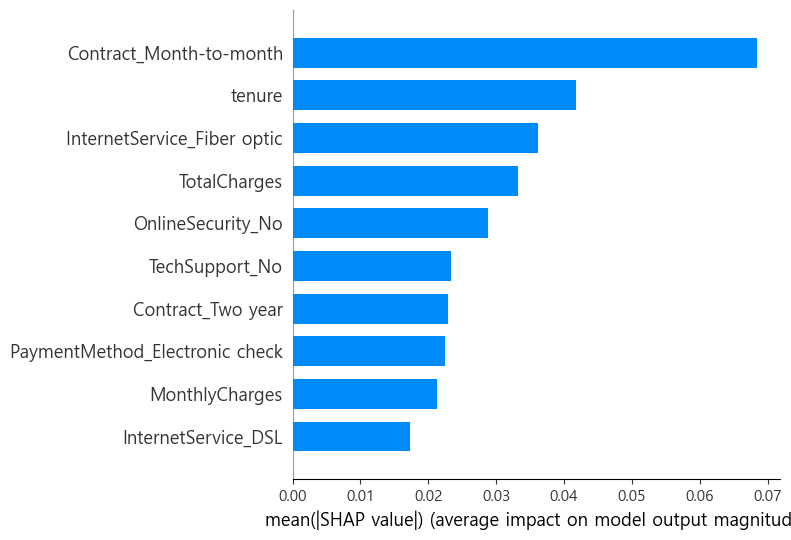

In [26]:
# ── Summary Plot Bar (변수 중요도 순위) ──────────────────────────
shap.summary_plot(shap_values[:, :, 1], X_test[best_features_mrmr],
                  plot_type='bar', max_display=10)

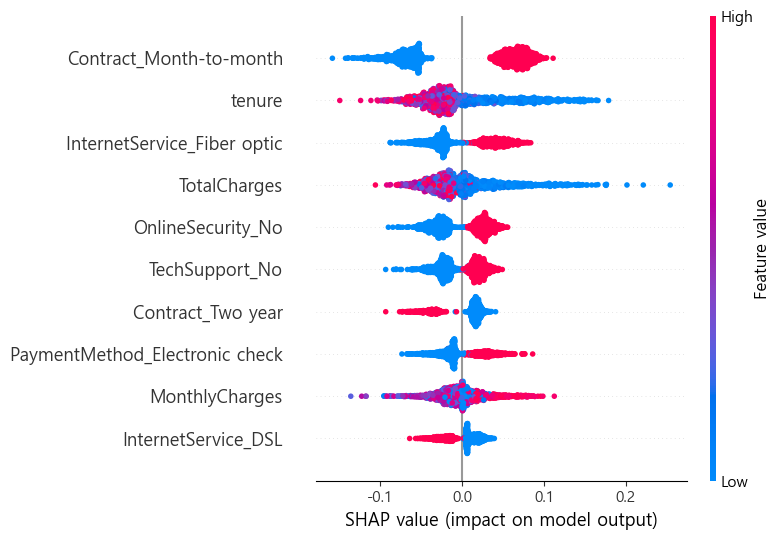

In [27]:
# ── Summary Plot Scatter (변수값 방향 포함) ───────────────────────
shap.summary_plot(shap_values[:, :, 1], X_test[best_features_mrmr], max_display=10)

**[과제]** 써니는 실제로 이탈(Churn=1)로 예측된 고객 한 명을 골라서 Force Plot으로 어떤 변수들이 이탈 예측에 기여했는지 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

In [ ]:
[프롬프트]

이탈(Churn=1)로 예측된 고객 한 명을 골라서
Force Plot을 그려보고 어떤 변수가 이탈 예측에 기여했는지 확인해보고 싶어.

관련 코드 작성해줘.

In [28]:
# ── 이탈(Churn=1)로 예측된 고객 인덱스 찾기 ─────────────────────
y_pred_train = rf_mrmr.predict(X_test[best_features_mrmr])
churn_indices = np.where(y_pred_train == 1)[0]

print(f"이탈로 예측된 고객 수: {len(churn_indices)}명")
print(f"첫 번째 이탈 예측 고객 인덱스: {churn_indices[0]}")

이탈로 예측된 고객 수: 301명
첫 번째 이탈 예측 고객 인덱스: 1


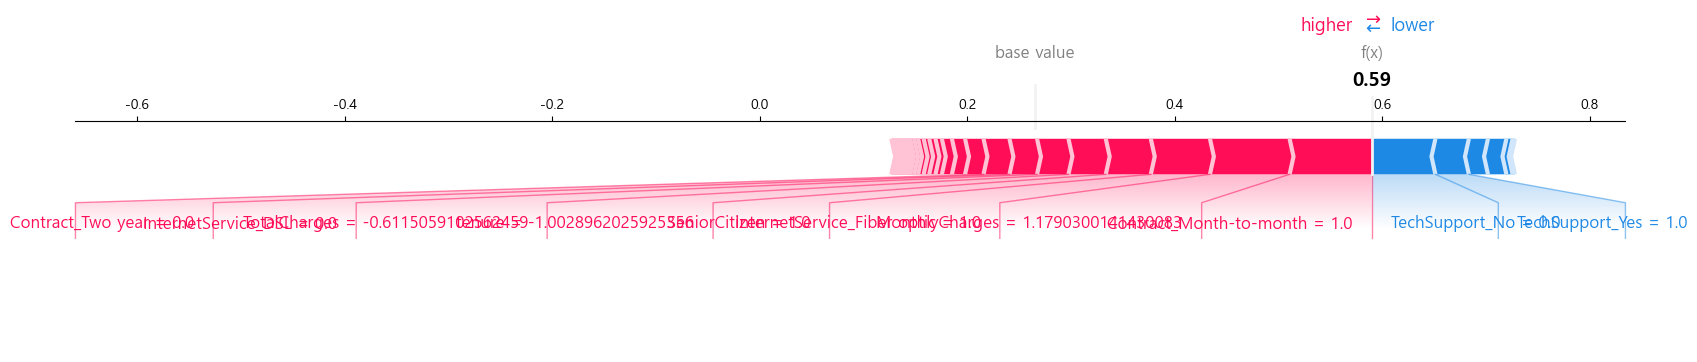

In [29]:
# ── Force Plot ────────────────────────────────────────────────────
idx = churn_indices[0]   # 이탈 예측 고객 1명 선택

# expected_value[1]: Churn=1 클래스의 기준값(base value)
# shap_values[idx, :, 1]: 해당 고객의 Churn=1에 대한 변수별 SHAP value

shap.force_plot(
    explainer.expected_value[1],
    shap_values[idx, :, 1],
    X_test[best_features_mrmr].iloc[idx],
    matplotlib=True
)

## 6) 분석 결과 종합 및 활용

**[과제]** 써니는 앞선 변수 선택 결과와 SHAP 분석을 종합해서, 이탈 고객을 막으려면 어떤 마케팅을 해야 할지 궁금합니다. AI와 상의하여 이탈로 예측된 고객들이 어떤 변수 때문에 그렇게 예측됐는지 파악하고 그에 맞는 마케팅 방식을 추천받아 보세요.

In [ ]:
[프롬프트]

앞에서 했던 Summary Plot, Force Plot을 활용해서
이탈하는 고객을 막기 위한 마케팅 전략을 세우고 싶어.

1. SHAP을 기반으로 이탈한 원인을 알 수 있는 코드 작성해주고
2. 1에 대한 결과를 주면 마케팅 전략 추천해줘.

In [35]:
# ── X_test 기준 SHAP 계산 ─────────────────────────────────────────
explainer = shap.TreeExplainer(rf_mrmr)
shap_values = explainer.shap_values(X_test[best_features_mrmr])
sv_churn = shap_values[:, :, 1]     # Churn=1 클래스 기준

In [36]:
# ── TP 고객만의 SHAP 평균 기여도 ─────────────────────────────────

sv_tp = sv_churn[tp_idx]
shap_mean = pd.Series(
    sv_tp.mean(axis=0),
    index=best_features_mrmr
).sort_values(ascending=False)
shap_abs_mean = pd.Series(
    np.abs(sv_tp).mean(axis=0),
    index=best_features_mrmr
).sort_values(ascending=False)

print("=== 실제 이탈 고객 - 이탈 기여 변수 (평균 SHAP) ===")
print(shap_mean.round(4).to_string())

=== 실제 이탈 고객 - 이탈 기여 변수 (평균 SHAP) ===
Contract_Month-to-month                    0.0809
tenure                                     0.0674
TotalCharges                               0.0544
InternetService_Fiber optic                0.0444
OnlineSecurity_No                          0.0286
TechSupport_No                             0.0215
Contract_Two year                          0.0197
InternetService_DSL                        0.0175
PaymentMethod_Electronic check             0.0165
MonthlyCharges                             0.0122
OnlineBackup_No                            0.0097
PaperlessBilling                           0.0094
DeviceProtection_No                        0.0084
OnlineSecurity_Yes                         0.0076
TechSupport_Yes                            0.0068
SeniorCitizen                              0.0059
StreamingTV_No internet service            0.0058
InternetService_No                         0.0055
StreamingMovies_No                         0.0054
DeviceProtec

> SHAP 기반 이탈 원인 분석 결과

| 순위 | 변수 | SHAP | 해석 |
|:---:|:---|:---:|:---|
| 1 | `Contract_Month-to-month` | 0.081 | 단기(월정기) 계약 고객이 이탈 가장 강하게 유발 |
| 2 | `tenure` | 0.067 | 가입 기간이 짧은 고객일수록 이탈 위험 높음 |
| 3 | `TotalCharges` | 0.054 | 누적 요금이 낮을수록(신규 고객) 이탈 위험 |
| 4 | `InternetService_Fiber optic` | 0.044 | 광랜 이용 고객의 이탈 비율 높음 |
| 5 | `OnlineSecurity_No` | 0.029 | 보안 서비스 미가입 고객 이탈 위험 |
| 6 | `TechSupport_No` | 0.022 | 기술 지원 미이용 고객 이탈 위험 |
| 7 | `PaymentMethod_Electronic check` | 0.017 | 전자결제 고객 이탈 위험 |
| 8 | `PaperlessBilling` | 0.009 | 전자고지서 고객 이탈 위험 |

---

> 마케팅 전략 추천

1. 단기 계약 고객 → 장기 전환 유도
- 월정기 계약 고객 대상 **1년/2년 약정 전환 시 요금 할인 또는 사은품** 제공
- "지금 약정 전환하면 월 XX% 할인" 타겟 푸시 알림 발송

2. 신규/단기 가입 고객 조기 이탈 방지
- 가입 후 **3개월 이내 고객** 집중 온보딩 프로그램 운영
- 첫 3개월 요금 할인 및 웰컴 혜택 강화로 초기 이탈율 감소

3. 광랜(Fiber optic) 고객 만족도 관리
- 광랜 고객 대상 **서비스 품질 만족도 설문** 및 선제적 불만 해소
- 요금 대비 가치 체감을 위한 속도·안정성 개선 홍보

4. 부가서비스 미가입 고객 락인(Lock-in) 유도
- `OnlineSecurity` + `TechSupport` 미가입 고객 → **무료 체험 1~3개월 제공**
- 부가서비스 묶음 할인으로 해지 비용 체감 효과 유도

5. 결제 방식 자동화 유도
- 전자수표(Electronic check) 고객 → **자동이체/신용카드 전환 시 청구 할인** 제공
- 결제 불편함 해소로 자연 이탈 방지